In [2]:
import numpy as np
import h5py
from scipy.io import loadmat
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.patches as patches

# Zak et al. 2020 data

In [3]:
fname = '../data/Zak_2020/Glomerular_Matrix.mat'
# f = h5py.File(fname, 'r')
resp = loadmat(fname)['Glomerular_Matrix']

#### With the matrix of 228 glomerular responses to 32 odors, the goal is to show that each odor has a handful of "private" glomeruli that can ignore the effects of backgrounds.

In [4]:
resp.shape

(228, 32)

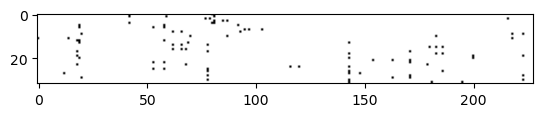

In [ ]:
# find 3-glomerulus barcodes
k = 3
top_k = []
for odor in resp.T:
    top_k.append(np.argsort(odor)[-k:])
top_k = np.array(top_k)

# plt.plot(top_k[:, 0], top_k[:, 1], '.')
barcode = np.zeros(resp.T.shape)
for odor_idx in range(len(barcode)):
    barcode[odor_idx][top_k[odor_idx]] = 1
plt.figure()
plt.imshow(barcode, cmap='Grays')

In [6]:
import numpy as np
from collections import Counter

# 1. sort each pair so smaller‐first
normalized = [tuple(sorted(pair)) for pair in top_k]

# 2. count with Counter
counts = Counter(normalized)

# now counts[(a,b)] is the number of times the unordered pair {a,b} appeared
# for pair, cnt in counts.items():
#     print(f"{pair}: {cnt}")


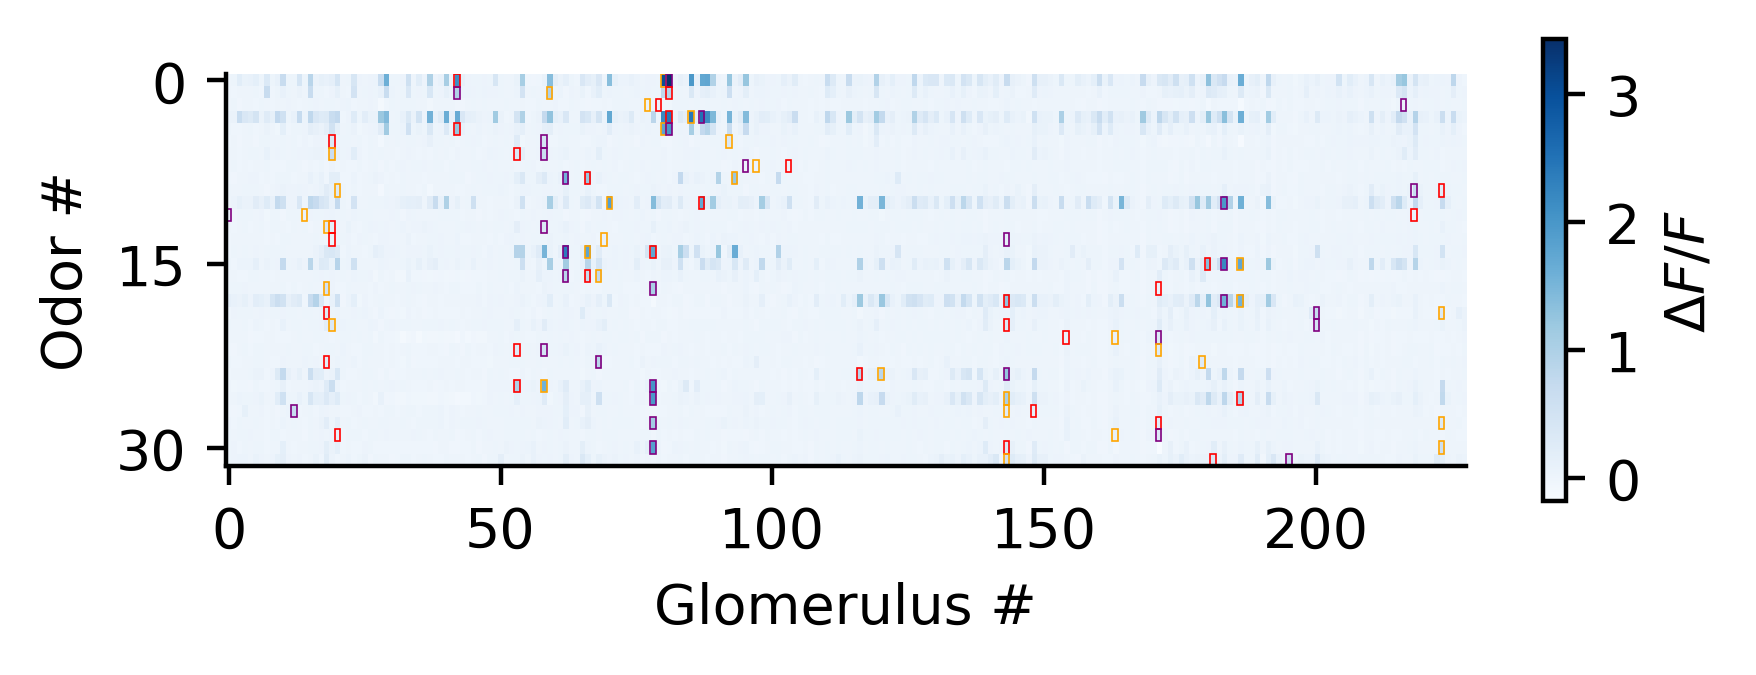

In [7]:
fig, ax = plt.subplots(figsize=(5,1.5), dpi=400)
cax = ax.imshow(resp.T, cmap='Blues', aspect=2.25)
# plt.imshow(resp.T, cmap='Blues') #, vmin=0, vmax=2.0)
fig.colorbar(mappable=cax, label='$\Delta F/F$')
ax.set_ylabel('Odor #')
ax.set_xlabel('Glomerulus #')
ax.set_yticks(np.arange(0, 32, 15))

# Coordinates to highlight (row, column)
highlight_coords = top_k
for odor_idx, top_gloms in enumerate(top_k):
    for kth_most, glom in enumerate(top_gloms):
        rect = patches.Rectangle(
            (glom - 0.5, odor_idx - 0.5),  # bottom-left corner in data coords
            1,                   # full width of one cell
            1,                   # full height of one cell
            linewidth=0.3,
            edgecolor=['r', 'orange', 'purple'][kth_most],
            facecolor='none',
            transform=ax.transData
        )
        ax.add_patch(rect)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)


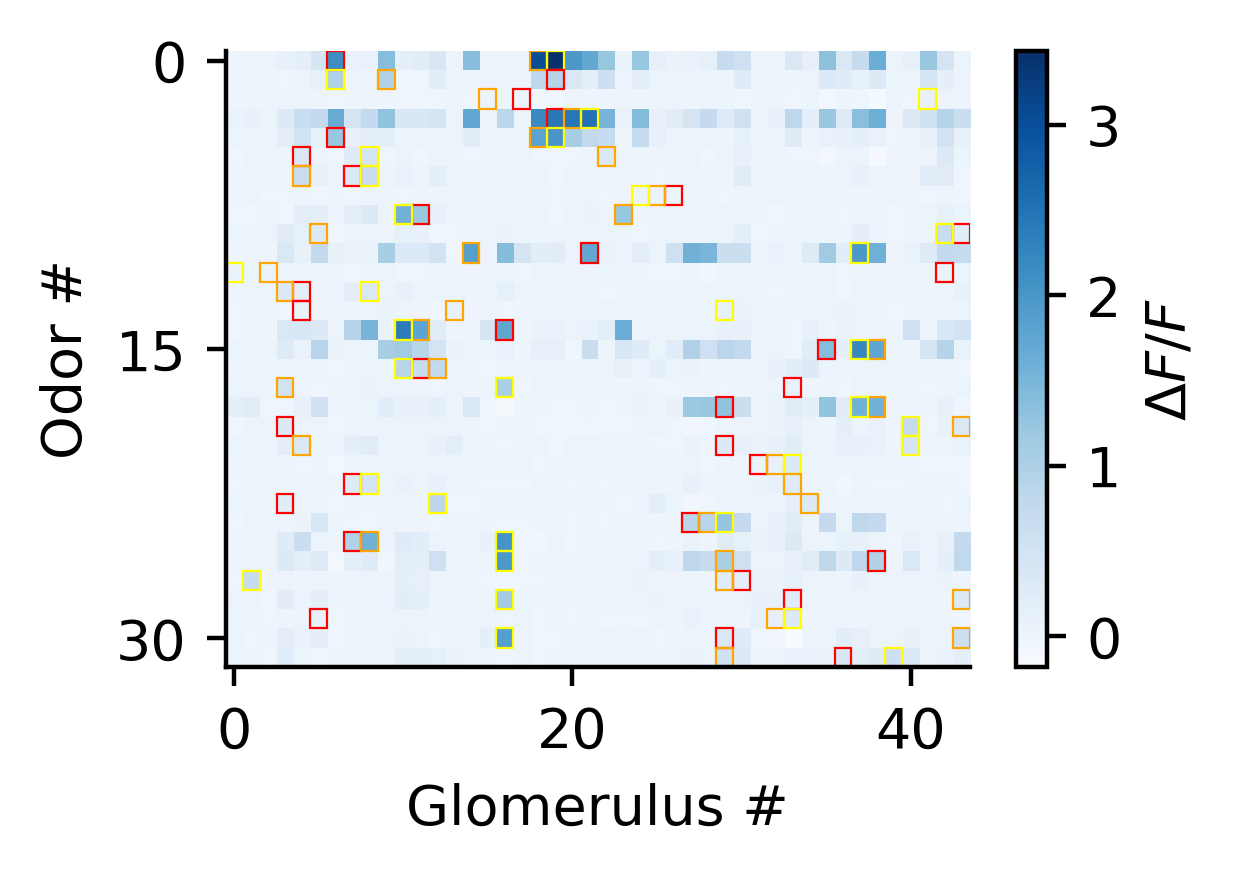

In [8]:
# --- 1) find which glomerulus‐columns actually get boxed ---
all_gloms = sorted({g for tops in top_k for g in tops})
# e.g. [0, 2, 5, 7, 9]

# --- 2) slice resp to only those gloms (rows of resp) ---
# filtered_resp: shape (len(all_gloms), n_odors)
filtered_resp = resp[all_gloms, :]

# --- 3) build a list of (odor_idx, new_glom_idx, rank) for drawing boxes ---
new_boxes = []
for odor_idx, tops in enumerate(top_k):
    for rank, old_g in enumerate(tops):
        if old_g in all_gloms:
            new_g = all_gloms.index(old_g)
            new_boxes.append((odor_idx, new_g, rank))

# --- 4) plot the trimmed heatmap & remapped boxes ---
fig, ax = plt.subplots(figsize=(3, 2), dpi=400)

# transpose so x→gloms, y→odors
cax = ax.imshow(filtered_resp.T, 
                cmap='Blues', 
                aspect='auto', 
                origin='upper')

fig.colorbar(cax, label='$\\Delta F/F$')
ax.set_xlabel('Glomerulus #')
ax.set_ylabel('Odor #')
ax.set_yticks(np.arange(0, resp.shape[1], 15))

# draw each box at (x=new_glom, y=odor)
colors = ['red','orange','yellow']
for odor_idx, new_g, rank in new_boxes:
    rect = patches.Rectangle(
        (new_g - 0.5, odor_idx - 0.5),  # x, y in data coords
        1, 1,                           # full cell size
        linewidth=0.4,
        edgecolor=colors[rank % len(colors)],
        facecolor='none',
        transform=ax.transData
    )
    ax.add_patch(rect)

# clean up spines & ticks
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.xaxis.set_ticks_position('bottom')
ax.yaxis.set_ticks_position('left')
plt.savefig('../figures/manuscript/glomerular_barcode.svg', dpi=600, bbox_inches='tight')
plt.savefig('../figures/manuscript/glomerular_barcode.png', dpi=600, bbox_inches='tight')

#### compare the population sparsity of the data with the model

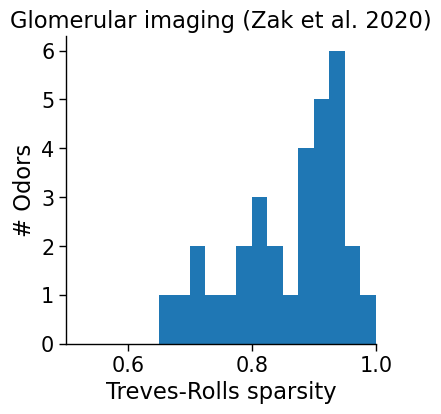

In [13]:
def population_sparsity(resp):
    '''
    resp: np.array with (glomeruli, odors)

    return
    np.array with (odors)
    '''
    N = len(resp)
    prefactor = 1# / (1 - 1/N)
    numerator = np.mean(resp, axis=0) ** 2
    denominator = np.mean(resp ** 2, axis=0) 
    return prefactor * (1 - numerator / denominator)


def treves_rolls_sparsity(responses):
    """
    responses: 1D numpy array (activity of neurons or of a single neuron over time)
    """
    N = len(responses)
    mean_r = np.mean(responses)
    mean_r2 = np.mean(responses**2)
    if mean_r2 == 0:
        return 0  # Avoid division by zero
    S = (mean_r**2) / mean_r2
    return 1 - S  # higher = more sparse


sparsity = population_sparsity(np.maximum(resp, 0))
sns.set_context("paper", font_scale=1.7)  # "talk", "notebook", "paper", "poster"
plt.figure(figsize=(4,4))
plt.hist(sparsity, bins=np.arange(0.5, 1.025, 0.025))
plt.xlabel('Treves-Rolls sparsity')
plt.ylabel('# Odors')
plt.title('Glomerular imaging (Zak et al. 2020)')
plt.xlim(0.5, 1.)
sns.despine()
plt.savefig('../figures/manuscript/glomerular_data_sparsity.svg', dpi=600, bbox_inches='tight')
plt.savefig('../figures/manuscript/glomerular_data_sparsity.png', dpi=600, bbox_inches='tight')